# HR Employee Attrition Analysis
## End-to-End Exploratory Data Analysis to Identify Drivers of Employee Turnover

## Project Overview

This project performs an end-to-end exploratory data analysis (EDA) on an HR employee dataset to identify the key drivers of employee attrition.

The objective is to uncover patterns related to compensation, job roles, workload, and employee satisfaction that influence turnover and provide data-driven recommendations to improve retention.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [6]:
df = pd.read_csv("hr_attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 📊 Data Understanding

We explore the dataset structure, data types, and summary statistics  
to understand the available features before performing analysis.

In [7]:
df.shape

(1470, 35)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 🧹 Data Quality Check

We check for missing values and duplicates to ensure data reliability.

In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
df.duplicated().sum()

np.int64(0)

## 📉 Attrition Rate Analysis

This section calculates the overall attrition rate  
to understand employee turnover.

In [12]:
attrition_rate = df["Attrition"].value_counts(normalize=True) * 100
attrition_rate

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## 📊 Attrition Distribution

Visualization of employees who stayed vs left.

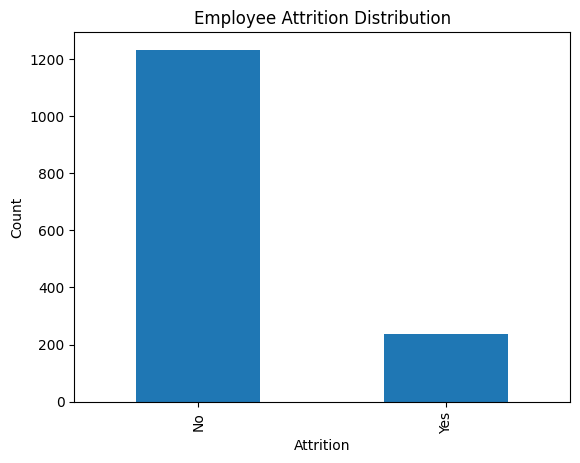

In [13]:
df["Attrition"].value_counts().plot(kind="bar")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.show()

## 🏢 Department vs Attrition

Analyzing which departments experience the highest employee turnover  
to identify high-risk areas in the organization.

In [14]:
dept_attrition = pd.crosstab(df["Department"], df["Attrition"])
dept_attrition

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


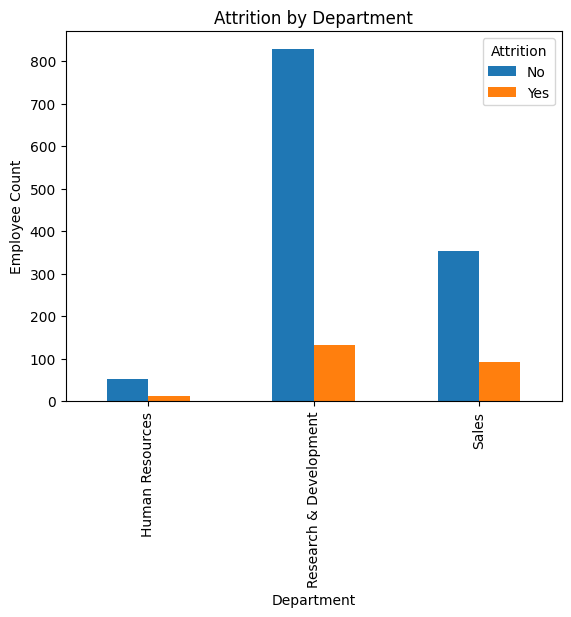

In [15]:
dept_attrition.plot(kind="bar")

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.show()

## 👩‍💼 Job Role vs Attrition

Understanding which job roles have the highest attrition  
helps HR focus retention strategies.

In [16]:
role_attrition = pd.crosstab(df["JobRole"], df["Attrition"])
role_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


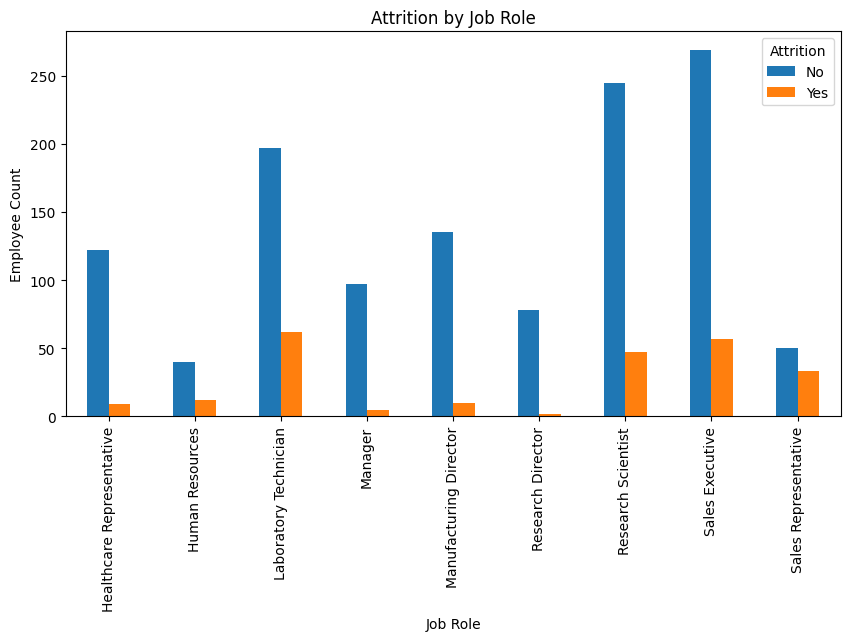

In [17]:
role_attrition.plot(kind="bar", figsize=(10,5))

plt.title("Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Employee Count")

plt.show()

## 💰 Salary vs Attrition

Comparing average monthly income of employees who left vs stayed  
to evaluate compensation impact.

In [18]:
df.groupby("Attrition")["MonthlyIncome"].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

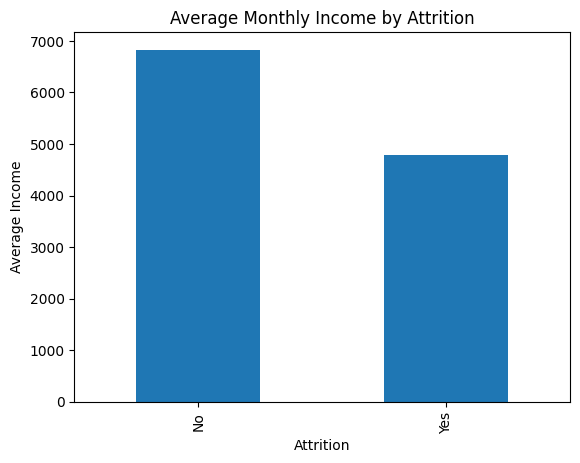

In [19]:
df.groupby("Attrition")["MonthlyIncome"].mean().plot(kind="bar")

plt.title("Average Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Income")

plt.show()

## ⏰ Overtime vs Attrition

Analyzing whether employees working overtime  
are more likely to leave the organization.

In [20]:
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"])
overtime_attrition

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


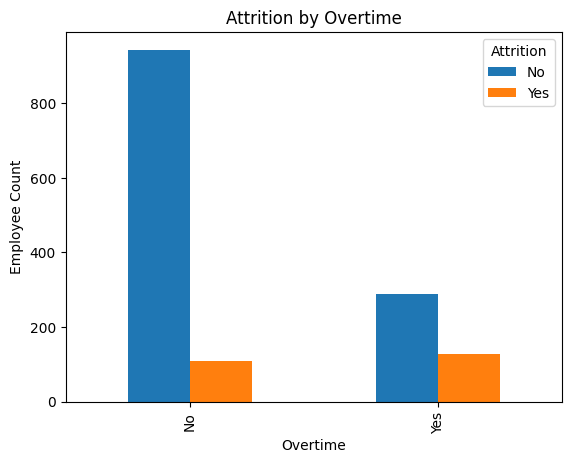

In [21]:
overtime_attrition.plot(kind="bar")

plt.title("Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.show()

## 🎂 Age Distribution by Attrition

Analyzing whether attrition is more common among  
younger or older employees.

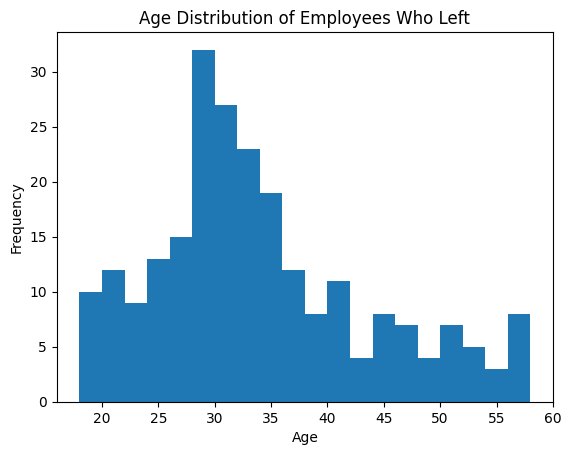

In [22]:
df[df["Attrition"] == "Yes"]["Age"].plot(kind="hist", bins=20)

plt.title("Age Distribution of Employees Who Left")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## 🔑 Key Insights

- The overall attrition rate indicates a significant employee turnover that requires strategic attention.
- Certain departments show higher attrition, suggesting workload, culture, or role expectations may vary.
- Specific job roles experience more turnover, indicating role-level dissatisfaction or career growth limitations.
- Employees with lower average monthly income tend to leave more frequently, highlighting compensation as a factor.
- Overtime shows a strong relationship with attrition, suggesting work-life balance challenges.
- Attrition appears more common among younger employees, indicating early-career mobility trends.

## 💡 Recommendations

- Improve retention strategies in high-attrition departments through targeted engagement programs.
- Review compensation structures to ensure competitive and fair pay.
- Monitor employees with frequent overtime and implement workload balancing.
- Introduce career development and mentorship programs for early-career employees.
- Conduct regular employee satisfaction surveys to proactively identify risk factors.

## 📌 Conclusion

This analysis identified key organizational and employee-level factors influencing attrition,  
including department, job role, compensation, and overtime.

By leveraging these insights, organizations can design targeted retention strategies,  
reduce hiring costs, and improve employee satisfaction.

The findings demonstrate how data-driven decision-making can support effective HR planning.

## ✅ Project Outcome

This project demonstrates an end-to-end exploratory data analysis workflow:

✔ Data understanding and cleaning  
✔ Attrition trend analysis  
✔ Factor impact evaluation  
✔ Business insights and recommendations  

The analysis provides actionable insights for improving employee retention.